In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("Tweets.csv")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [3]:
texts = df['text'].astype(str)
labels = df['sentiment']

In [4]:
le = LabelEncoder()
y = le.fit_transform(labels)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42
)

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Fix missing values
X_train = X_train.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

In [9]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(X_train_seq, maxlen=50)
X_test_pad = pad_sequences(X_test_seq, maxlen=50)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([
    Embedding(10000, 64, input_length=50),
    SimpleRNN(64),
    Dense(3, activation='softmax')
])

c:\Users\avina\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [12]:
rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [13]:
rnn_model.fit(X_train_pad, y_train, epochs=5, batch_size=128)

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4972 - loss: 0.9902
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7344 - loss: 0.6584
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8679 - loss: 0.3737
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9429 - loss: 0.1848
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9682 - loss: 0.1115


In [14]:
rnn_acc = rnn_model.evaluate(X_test_pad, y_test)[1]

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6353 - loss: 1.2362


In [15]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(10000, 64, input_length=50),
    LSTM(64),
    Dense(3, activation='softmax')
])

In [16]:
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.fit(X_train_pad, y_train, epochs=5, batch_size=128)

lstm_acc = lstm_model.evaluate(X_test_pad, y_test)[1]

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.5330 - loss: 0.9429
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7344 - loss: 0.6406
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.7972 - loss: 0.5147
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.8324 - loss: 0.4403
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.8564 - loss: 0.3839
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6955 - loss: 0.8100


In [17]:
print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)

RNN Accuracy: 0.6352555751800537
LSTM Accuracy: 0.6954702734947205


In [18]:
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test_pad, y_test)
)

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9824 - loss: 0.0654 - val_accuracy: 0.6138 - val_loss: 1.4694
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9876 - loss: 0.0484 - val_accuracy: 0.6047 - val_loss: 1.6094
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9912 - loss: 0.0341 - val_accuracy: 0.6085 - val_loss: 1.7544
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9943 - loss: 0.0255 - val_accuracy: 0.6225 - val_loss: 1.7832
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9941 - loss: 0.0224 - val_accuracy: 0.6158 - val_loss: 1.9370
Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.8761 - loss: 0.3436 - val_accuracy: 0.6900 - val_loss: 0.8677
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.8898 - loss: 0.3057 - val_accuracy: 0.6862 - val_loss: 0.9430
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9061 - loss: 0.2698 - val_accuracy:

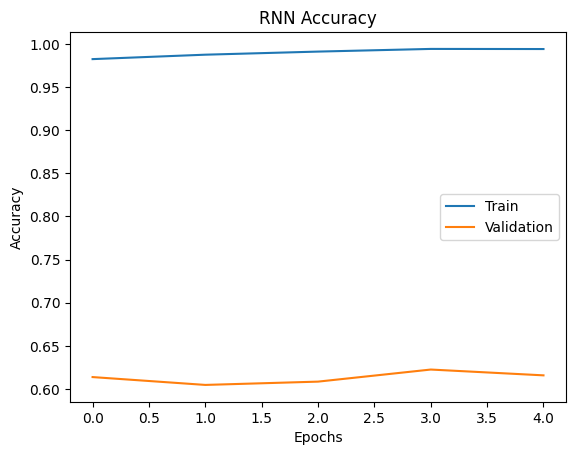

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(rnn_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])
plt.title("RNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

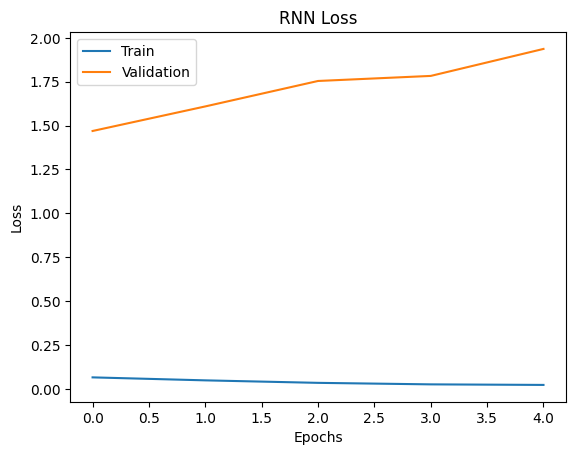

In [20]:
plt.figure()
plt.plot(rnn_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])
plt.title("RNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

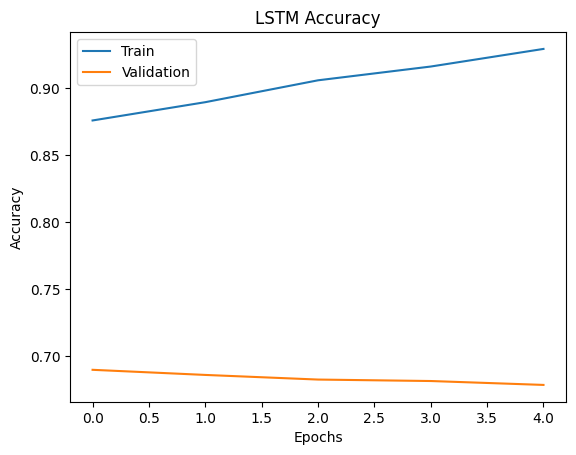

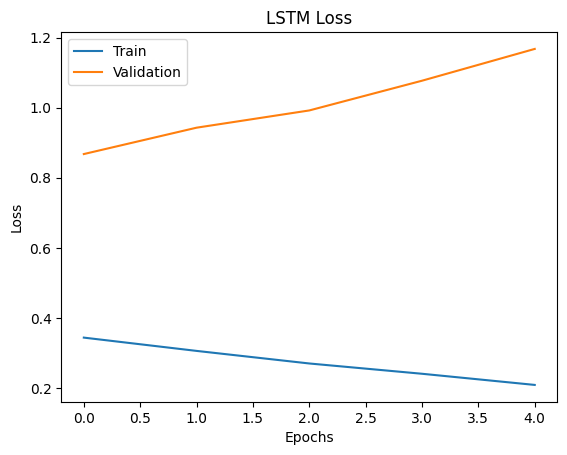

In [22]:
plt.figure()
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])
plt.title("LSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()



plt.figure()
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title("LSTM Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

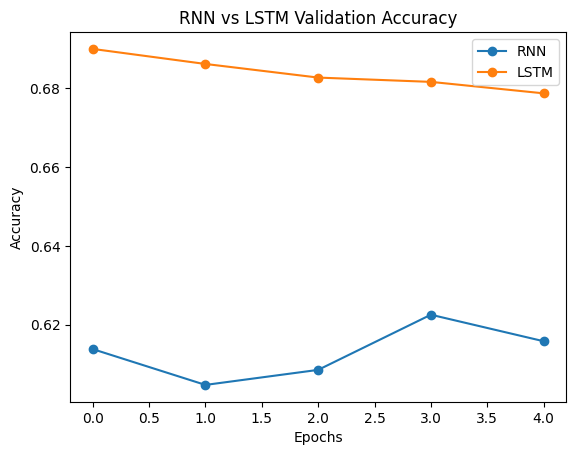

In [25]:
import matplotlib.pyplot as plt

plt.figure()

# RNN Accuracy
plt.plot(rnn_history.history['val_accuracy'], marker='o')

# LSTM Accuracy
plt.plot(lstm_history.history['val_accuracy'], marker='o')

plt.title("RNN vs LSTM Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["RNN", "LSTM"])

plt.show()

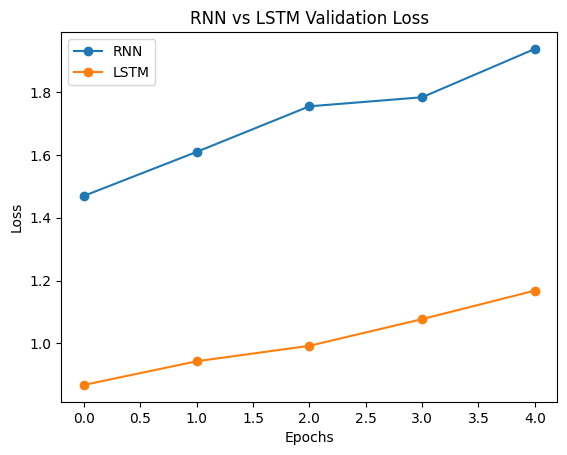

In [26]:
plt.figure()

# RNN Loss
plt.plot(rnn_history.history['val_loss'], marker='o')

# LSTM Loss
plt.plot(lstm_history.history['val_loss'], marker='o')

plt.title("RNN vs LSTM Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["RNN", "LSTM"])

plt.show()